# ¿De dónde vino el planeta que chocó contra la Tierra?

**Hace 4.500 millones de años, otro planeta — del tamaño de Marte — chocó contra la proto-Tierra. De ese choque salió la Luna.** El paper lo llama Theia, pero nadie sabía dónde se había formado: ¿cerca del Sol, como Mercurio y Venus, o lejos, donde están los asteroides carbonáceos?

Este equipo midió **isótopos de hierro (μ⁵⁴Fe) en 41 muestras** — terrestres, lunares y meteoríticas — y los cruzó con cinco sistemas isotópicos más (Cr, Ti, O, Zr, Mo). Después corrieron un balance de masas para reconstruir cómo tendría que haber sido Theia.

📄 **Paper:** Hopp et al. (2025), *Science*. [DOI: 10.1126/science.ado0623](https://doi.org/10.1126/science.ado0623)
🎬 **Video:** [Ver en YouTube](https://youtube.com/shorts/DB475dAgomA)
🚀 **Reproducir:** [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2025-11-20-theia-sistema-solar-interior/notebook.ipynb)

## Lo que tenemos en la mesa

Tres tablas del Supplementary del paper:

- **41 muestras Fe individuales** — 15 terrestres, 6 lunares, 14 enstatitas, 4 condritas ordinarias, 2 Rumuruti. La columna `exposicion_gcr` marca cuáles muestras lunares fueron golpeadas mucho tiempo por rayos cósmicos galácticos (GCR — partículas de alta energía que vienen de fuera del Sistema Solar). Eso altera el μ⁵⁴Fe — hay que filtrarlo.
- **27 promedios cross-isotope** — un resumen por clase de meteorito en seis sistemas isotópicos (O, Ti, Cr, Fe, Zr, Mo). La columna `reservoir` clasifica cada clase como **NC** (no carbonáceo, Sistema Solar interior) o **CC** (carbonáceo, exterior).
- **12 escenarios de balance de masas** — qué composición isotópica tendría Theia bajo 4 supuestos de manto terrestre (PEM) × 3 tamaños de impactor.

Vamos por partes.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_NC = '#2563EB'        # No carbonáceo (Sistema Solar interior) — azul
COLOR_CC = '#DC2626'        # Carbonáceo (exterior) — rojo
COLOR_EARTH = '#059669'     # Tierra — emerald
COLOR_MOON = '#7C3AED'      # Luna — violeta
COLOR_THEIA = '#D97706'     # Theia calculada — amber
FUENTE = 'Fuente: Hopp et al. (2025), Science | Datos: Supplementary Materials, doi:10.1126/science.ado0623'

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Carga del estilo CaM (local en Colab → fallback a GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

# Datos
fe_ind = pd.read_csv('datos/fe_isotopes_individual.csv')
iso_summary = pd.read_csv('datos/isotope_summary.csv')
mass_balance = pd.read_csv('datos/theia_mass_balance.csv')

print(f'fe_isotopes_individual: {len(fe_ind)} muestras × {len(fe_ind.columns)} columnas')
print(f'   {fe_ind["grupo"].value_counts().to_dict()}')
print()
print(f'isotope_summary: {len(iso_summary)} clases × {len(iso_summary.columns)} columnas')
print(f'   reservoirs: {iso_summary["reservoir"].value_counts().to_dict()}')
print()
print(f'theia_mass_balance: {len(mass_balance)} escenarios = '
      f'{mass_balance["pem_supuesto"].nunique()} PEMs × {mass_balance["tamano_impactor"].nunique()} tamaños')

fe_isotopes_individual: 41 muestras × 10 columnas
   {'Terrestrial samples': 15, 'Enstatite chondrites': 14, 'Lunar samples': 6, 'Ordinary chondrites': 4, 'Rumuruti chondrites': 2}

isotope_summary: 27 clases × 15 columnas
   reservoirs: {'NC': 17, 'CC': 8, 'EARTH': 1, 'MOON': 1}

theia_mass_balance: 12 escenarios = 4 PEMs × 3 tamaños


## La pregunta de fondo

Cuando un meteorito cae a la Tierra, su composición isotópica nos dice de qué parte del Sistema Solar nació. **Hay dos familias claras**: los condritos no carbonáceos (NC), formados cerca del Sol; y los carbonáceos (CC), formados más lejos. Si plotean dos isótopos cualquiera, las dos familias se separan.

¿Dónde caen la Tierra y la Luna en ese mapa?

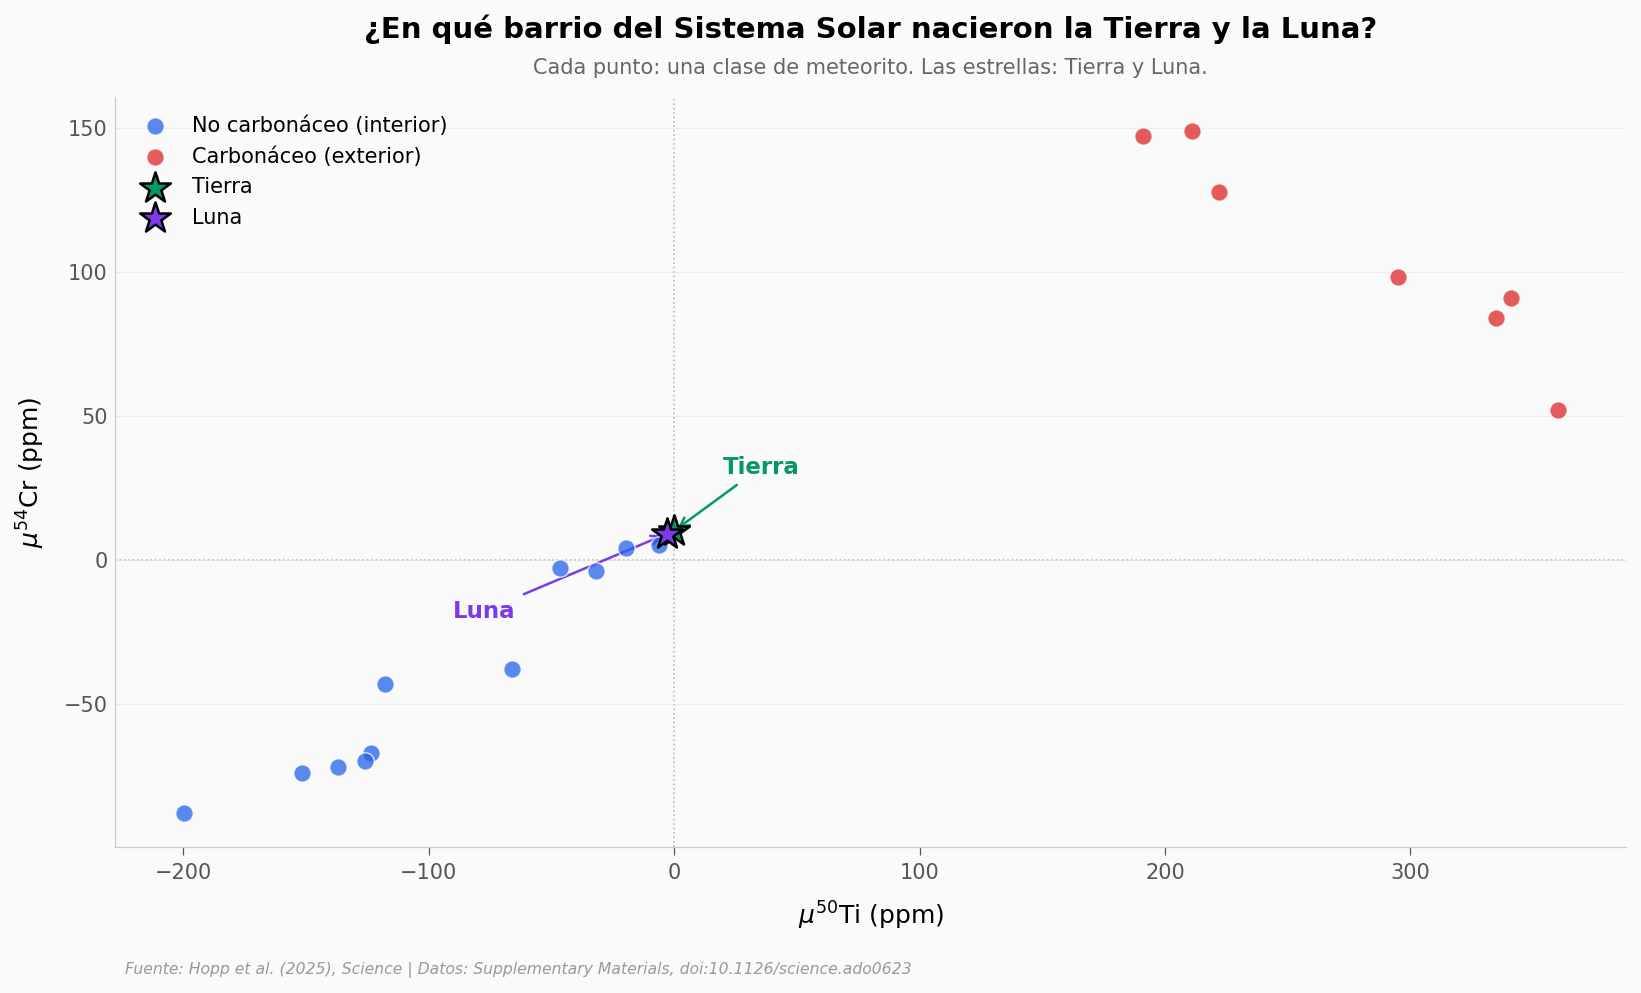

In [2]:
# Gráfica hero: el biplot que separa NC vs CC
fig, ax = plt.subplots(figsize=(13, 6.5))

# Muestras (filtramos las que tienen ambos isótopos)
mask = iso_summary['mu54Cr'].notna() & iso_summary['mu50Ti'].notna()
df = iso_summary[mask].copy()

for reservoir, color, label in [
    ('NC', COLOR_NC, 'No carbonáceo (interior)'),
    ('CC', COLOR_CC, 'Carbonáceo (exterior)'),
]:
    sub = df[df['reservoir'] == reservoir]
    ax.scatter(sub['mu50Ti'], sub['mu54Cr'], color=color, s=70, alpha=0.75,
               edgecolors='white', linewidths=0.7, label=label, zorder=4)

# Tierra y Luna — destacados
earth = df[df['reservoir'] == 'EARTH']
moon = df[df['reservoir'] == 'MOON']
ax.scatter(earth['mu50Ti'], earth['mu54Cr'], color=COLOR_EARTH, s=240,
           marker='*', edgecolors='black', linewidths=1.2, zorder=6, label='Tierra')
ax.scatter(moon['mu50Ti'], moon['mu54Cr'], color=COLOR_MOON, s=240,
           marker='*', edgecolors='black', linewidths=1.2, zorder=6, label='Luna')

# Anotar Earth/Moon
ax.annotate('Tierra', xy=(0, 10), xytext=(20, 30), fontsize=11,
            fontweight='bold', color=COLOR_EARTH,
            arrowprops=dict(arrowstyle='->', color=COLOR_EARTH, lw=1.2))
ax.annotate('Luna', xy=(-3, 9), xytext=(-90, -20), fontsize=11,
            fontweight='bold', color=COLOR_MOON,
            arrowprops=dict(arrowstyle='->', color=COLOR_MOON, lw=1.2))

# Linea de cero (origen)
ax.axhline(0, color='#BBBBBB', linewidth=0.8, linestyle=':', zorder=1)
ax.axvline(0, color='#BBBBBB', linewidth=0.8, linestyle=':', zorder=1)

ax.set_xlabel(r'$\mu^{50}$Ti (ppm)', fontsize=12)
ax.set_ylabel(r'$\mu^{54}$Cr (ppm)', fontsize=12)
ax.set_title('¿En qué barrio del Sistema Solar nacieron la Tierra y la Luna?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto: una clase de meteorito. Las estrellas: Tierra y Luna.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(loc='upper left', fontsize=10, framealpha=0.92)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_biplot_cr_ti.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que llama la atención

Tierra y Luna caen en el extremo del campo no carbonáceo, casi pegadas al cero — apenas por encima del límite superior NC en μ⁵⁴Cr y dentro del rango NC en μ⁵⁰Ti. La distancia a los carbonáceos (CC) es enorme — μ⁵⁰Ti pasa de cero a más de doscientas unidades; μ⁵⁴Cr salta de diez a más de cien.

**Y la Luna y la Tierra caen casi en el mismo punto.** Eso significa que el material que las formó — incluyendo Theia — venía del mismo lado del Sistema Solar: el interior. Pero antes de cantar victoria, hay un dato lunar que parecía romper el patrón. Veámoslo.

## El problema del hierro lunar

Si miras las muestras lunares en bruto, el μ⁵⁴Fe parece **mucho más alto** que en la Tierra. Eso encendió alarmas durante años: si la Luna tiene firma de Fe distinta, quizás Theia no era tan parecida a la Tierra.

La trampa: la Luna no tiene atmósfera. Los rayos cósmicos galácticos (GCR) bombardean la superficie lunar durante millones de años y **alteran el μ⁵⁴Fe** — lo suben artificialmente. Cuando filtramos solo las muestras de **baja exposición** a GCR, el efecto se desvanece.

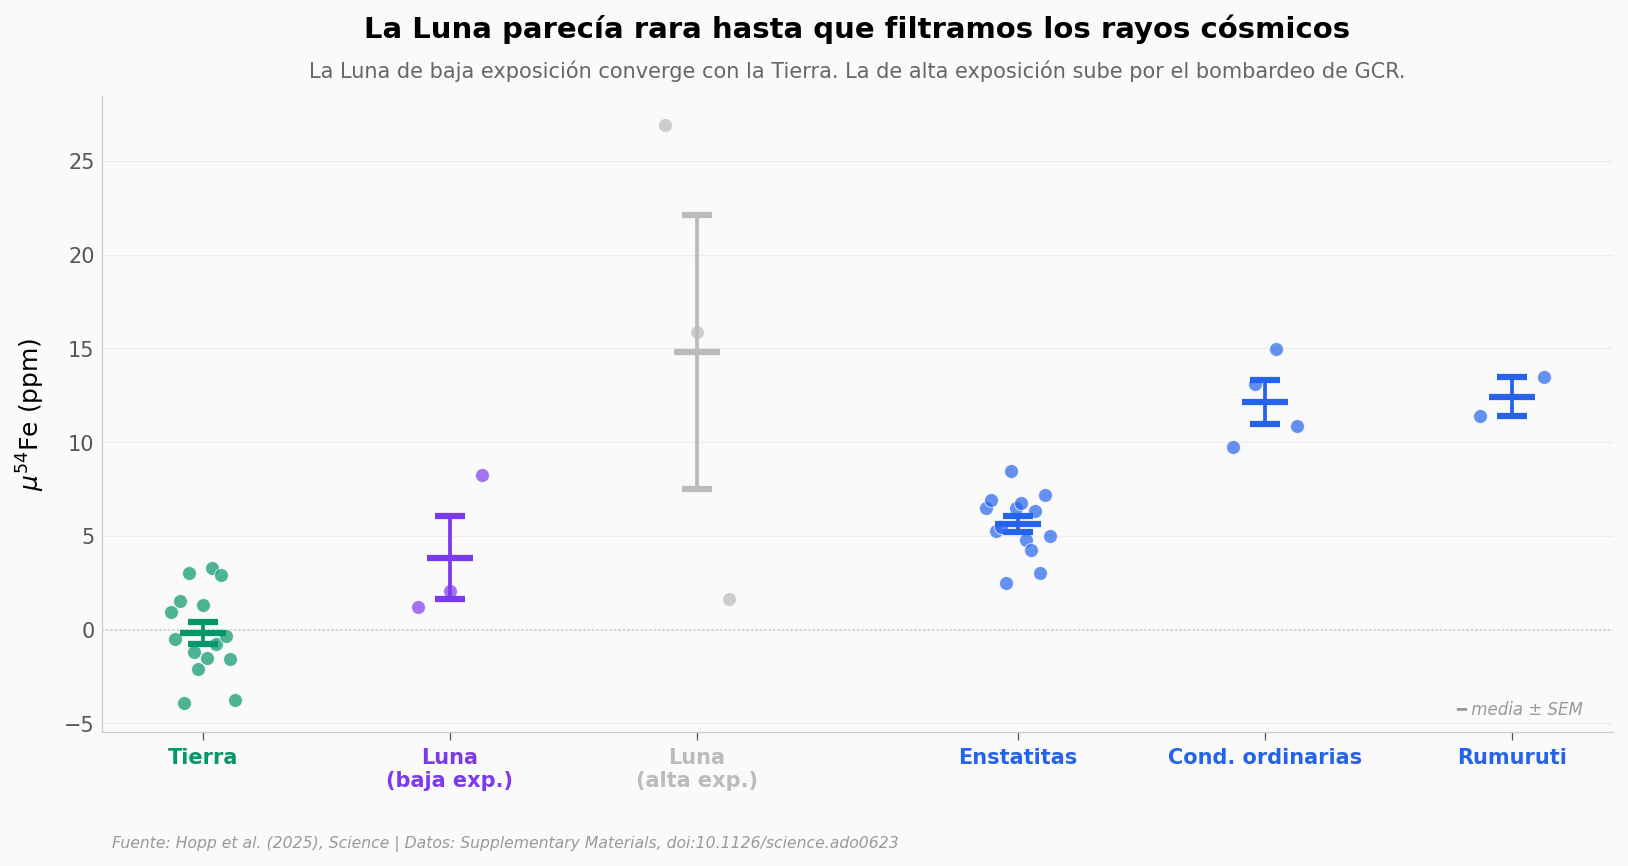

Mann-Whitney Tierra vs Luna (todas):       p = 0.0062
Mann-Whitney Tierra vs Luna (baja exp.):   p = 0.1005
Tierra:        media = -0.16 ppm  (n=15)
Luna baja:     media = +3.84 ppm  (n=3)
Luna alta:     media = +14.81 ppm  (n=3)


In [3]:
# Strip plot de μ54Fe — Tierra vs Luna (raw vs corregida) vs condritos NC
fig, ax = plt.subplots(figsize=(13, 5.5))

# Subgrupos
terrestrial = fe_ind[fe_ind['grupo'] == 'Terrestrial samples']['mu54Fe'].values
lunar_all = fe_ind[fe_ind['grupo'] == 'Lunar samples']
lunar_low = lunar_all[lunar_all['exposicion_gcr'] == 'baja']['mu54Fe'].values
lunar_high = lunar_all[lunar_all['exposicion_gcr'] == 'alta']['mu54Fe'].values
ec = fe_ind[fe_ind['grupo'] == 'Enstatite chondrites']['mu54Fe'].values
oc = fe_ind[fe_ind['grupo'] == 'Ordinary chondrites']['mu54Fe'].values
rc = fe_ind[fe_ind['grupo'] == 'Rumuruti chondrites']['mu54Fe'].values

groups = [
    ('Tierra', terrestrial, COLOR_EARTH),
    ('Luna\n(baja exp.)', lunar_low, COLOR_MOON),
    ('Luna\n(alta exp.)', lunar_high, '#BBBBBB'),
    ('Enstatitas', ec, COLOR_NC),
    ('Cond. ordinarias', oc, COLOR_NC),
    ('Rumuruti', rc, COLOR_NC),
]

# Posiciones — gap entre grupos terrestres/lunares y meteoritos
positions = [0, 1, 2, 3.3, 4.3, 5.3]

np.random.seed(42)
for (label, vals, color), pos in zip(groups, positions):
    n = len(vals)
    x_strip = np.linspace(pos - 0.13, pos + 0.13, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=45, alpha=0.7,
               edgecolors='white', linewidths=0.5, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n) if n > 1 else 0
    ax.errorbar(pos, mean, yerr=sem, fmt='_', color=color, markersize=22,
                markeredgewidth=3, capsize=7, capthick=1.5, zorder=6)

# Línea cero
ax.axhline(0, color='#BBBBBB', linewidth=0.8, linestyle=':', zorder=1)

ax.set_xticks(positions)
ax.set_xticklabels([g[0] for g in groups], fontsize=10, fontweight='bold')
for tick, (_, _, color) in zip(ax.get_xticklabels(), groups):
    tick.set_color(color)

ax.set_ylabel(r'$\mu^{54}$Fe (ppm)', fontsize=12)
ax.set_title('La Luna parecía rara hasta que filtramos los rayos cósmicos',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'La Luna de baja exposición converge con la Tierra. La de alta exposición sube por el bombardeo de GCR.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Nota error bars
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_fe_por_grupo.png', dpi=200, bbox_inches='tight')
plt.show()

# Tests resumidos
mw_raw = stats.mannwhitneyu(terrestrial,
                            lunar_all['mu54Fe'].values, alternative='two-sided')
mw_low = stats.mannwhitneyu(terrestrial, lunar_low, alternative='two-sided')
print(f'Mann-Whitney Tierra vs Luna (todas):       p = {mw_raw.pvalue:.4f}')
print(f'Mann-Whitney Tierra vs Luna (baja exp.):   p = {mw_low.pvalue:.4f}')
print(f'Tierra:        media = {terrestrial.mean():+.2f} ppm  (n={len(terrestrial)})')
print(f'Luna baja:     media = {lunar_low.mean():+.2f} ppm  (n={len(lunar_low)})')
print(f'Luna alta:     media = {lunar_high.mean():+.2f} ppm  (n={len(lunar_high)})')

## El cálculo de Theia

Tierra y Luna comparten composición isotópica. Pero **Theia no es la Tierra actual** — es uno de los dos cuerpos que se mezclaron en el impacto. Para reconstruir la composición de Theia hay que asumir cómo era el manto de la proto-Tierra (PEM, por *Proto-Earth Mantle*) **antes** del choque, y qué fracción de cada elemento aportó Theia al manto actual (xCr, xFe, xMo — la fracción de Cr, Fe y Mo terrestres que vino del impactor).

El equipo probó **cuatro recetas de PEM** (Enstatitas, Ordinarias, CI, CV) cruzadas con **tres tamaños de impactor** (canónico ~10% de la Tierra, half-Earth, pequeño). Doce escenarios. ¿Cuál da una Theia que existe en la naturaleza?

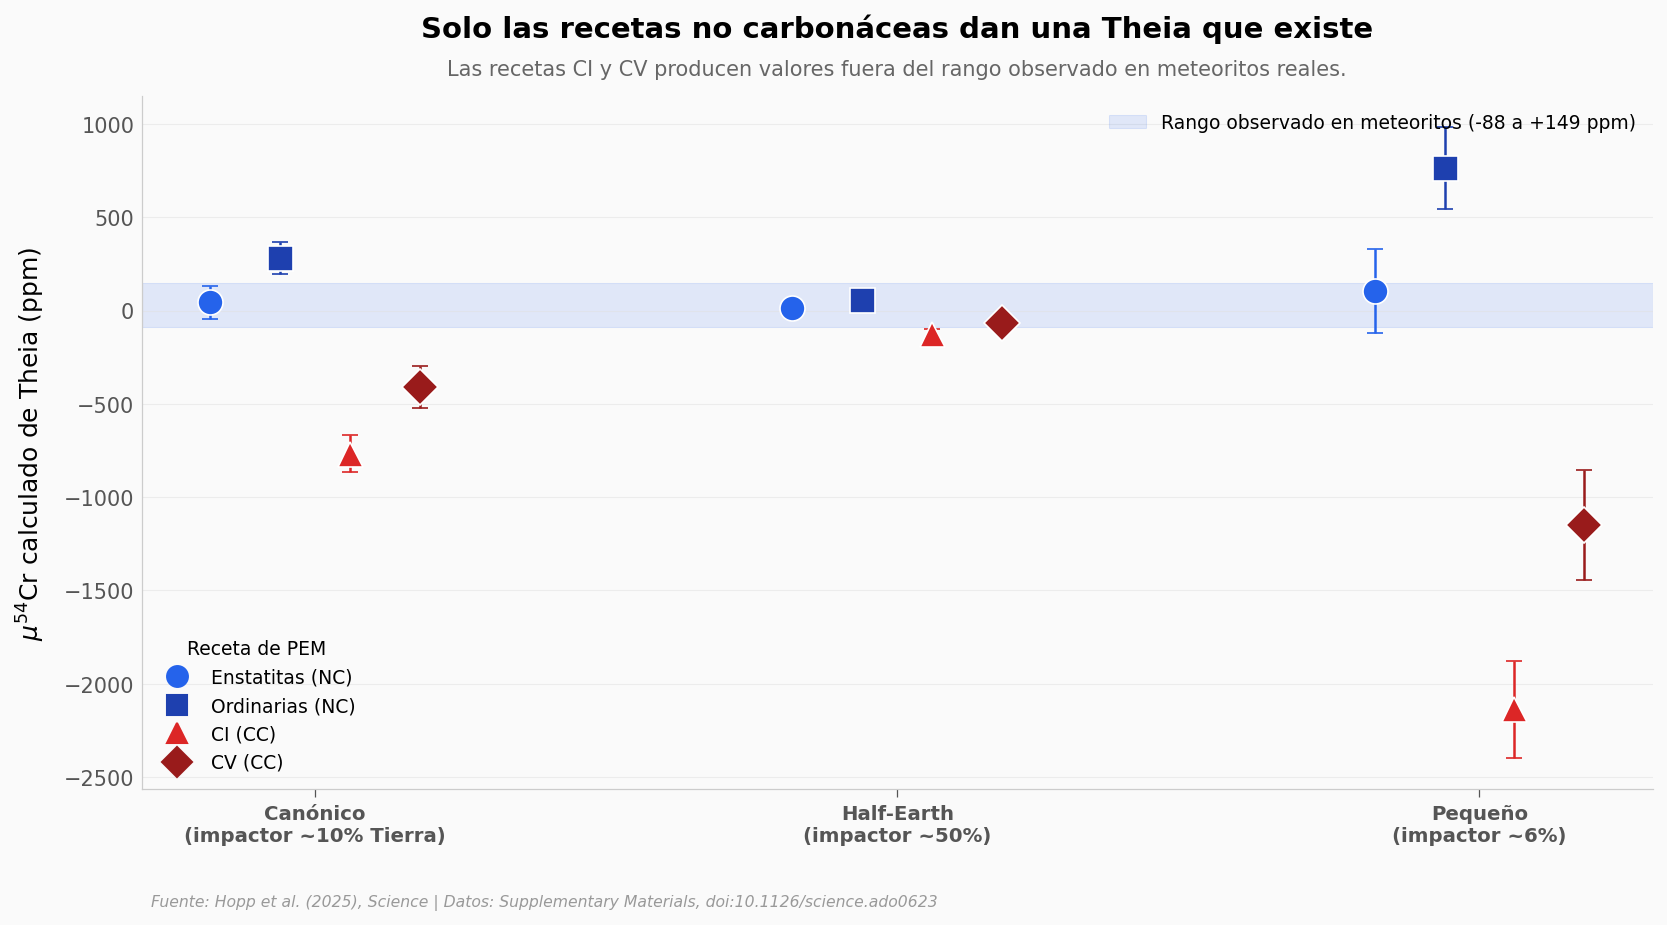

Theia calculada (μ54Cr) — escenario canónico:
   Enstatite chondrites     :   +44 ± 90 ppm  → ✓ plausible
   Ordinary chondrites      :  +282 ± 87 ppm  → ✗ FUERA del rango
   CI chondrites            :  -766 ± 101 ppm  → ✗ FUERA del rango
   CV chondrites            :  -409 ± 114 ppm  → ✗ FUERA del rango


In [4]:
# Mass balance: μ54Cr de Theia bajo cada combinación PEM × tamaño
fig, ax = plt.subplots(figsize=(13, 6))

# Rango plausible: el min/max observado en meteoritos reales
mu54Cr_observados = iso_summary['mu54Cr'].dropna().values
plausible_lo, plausible_hi = mu54Cr_observados.min(), mu54Cr_observados.max()

# Sombra del rango plausible
ax.axhspan(plausible_lo, plausible_hi, alpha=0.12, color='#2563EB', zorder=1,
           label=f'Rango observado en meteoritos ({plausible_lo:.0f} a +{plausible_hi:.0f} ppm)')

# Puntos por escenario
tamano_pos = {'Canonical': 0, 'Half-Earth': 1, 'Small': 2}
pem_color = {
    'Enstatite chondrites': COLOR_NC,
    'Ordinary chondrites': '#1E40AF',
    'CI chondrites': COLOR_CC,
    'CV chondrites': '#991B1B',
}
pem_marker = {
    'Enstatite chondrites': 'o',
    'Ordinary chondrites': 's',
    'CI chondrites': '^',
    'CV chondrites': 'D',
}

# Jitter pequeño para separar PEMs en el mismo tamaño
pem_offset = {
    'Enstatite chondrites': -0.18,
    'Ordinary chondrites': -0.06,
    'CI chondrites': 0.06,
    'CV chondrites': 0.18,
}

for _, row in mass_balance.iterrows():
    x = tamano_pos[row['tamano_impactor']] + pem_offset[row['pem_supuesto']]
    ax.errorbar(x, row['mu54Cr_theia'], yerr=row['mu54Cr_95CI'],
                fmt=pem_marker[row['pem_supuesto']],
                color=pem_color[row['pem_supuesto']],
                markersize=12, markeredgecolor='white', markeredgewidth=0.8,
                capsize=4, capthick=1, elinewidth=1.2, zorder=5)

# Leyenda manual por PEM
import matplotlib.lines as mlines
handles = [
    mlines.Line2D([], [], marker='o', color=COLOR_NC, linestyle='',
                  markersize=10, label='Enstatitas (NC)'),
    mlines.Line2D([], [], marker='s', color='#1E40AF', linestyle='',
                  markersize=10, label='Ordinarias (NC)'),
    mlines.Line2D([], [], marker='^', color=COLOR_CC, linestyle='',
                  markersize=10, label='CI (CC)'),
    mlines.Line2D([], [], marker='D', color='#991B1B', linestyle='',
                  markersize=10, label='CV (CC)'),
]
leg1 = ax.legend(handles=handles, title='Receta de PEM', loc='lower left',
                 fontsize=9, title_fontsize=9, framealpha=0.92)
ax.add_artist(leg1)
ax.legend(loc='upper right', fontsize=9, framealpha=0.92)

ax.set_xticks(list(tamano_pos.values()))
ax.set_xticklabels(['Canónico\n(impactor ~10% Tierra)',
                    'Half-Earth\n(impactor ~50%)',
                    'Pequeño\n(impactor ~6%)'],
                   fontsize=9.5, fontweight='bold')
ax.set_ylabel(r'$\mu^{54}$Cr calculado de Theia (ppm)', fontsize=12)
ax.set_title('Solo las recetas no carbonáceas dan una Theia que existe',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Las recetas CI y CV producen valores fuera del rango observado en meteoritos reales.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_mass_balance.png', dpi=200, bbox_inches='tight')
plt.show()

# Resumen
print('Theia calculada (μ54Cr) — escenario canónico:')
canonical = mass_balance[mass_balance['tamano_impactor'] == 'Canonical']
for _, r in canonical.iterrows():
    plausible = '✓ plausible' if plausible_lo <= r['mu54Cr_theia'] <= plausible_hi else '✗ FUERA del rango'
    print(f'   {r["pem_supuesto"]:25s}: {r["mu54Cr_theia"]:+5.0f} ± {r["mu54Cr_95CI"]:.0f} ppm  → {plausible}')

## El golpe final

Pongamos la μ⁵⁴Cr de Theia (canónico, las cuatro PEMs) junto a la distribución real de meteoritos. ¿Cuáles caen dentro?

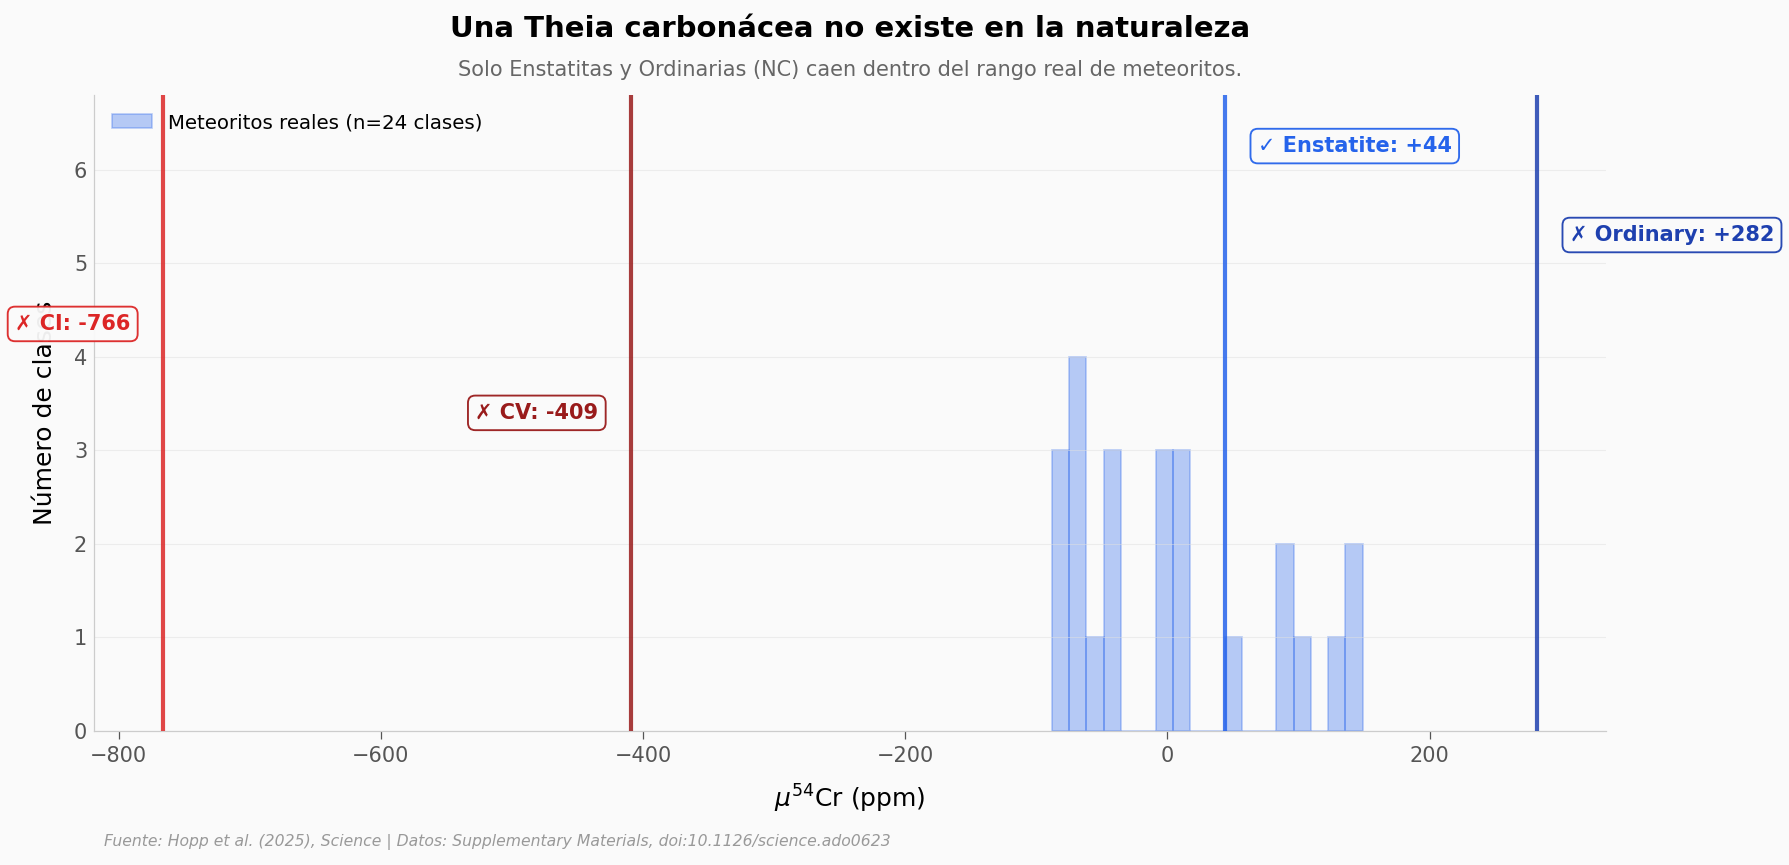

In [5]:
# Histograma de μ54Cr observados + líneas de Theia calculada bajo cada PEM
pem_color_local = {
    'Enstatite chondrites': COLOR_NC,
    'Ordinary chondrites': '#1E40AF',
    'CI chondrites': COLOR_CC,
    'CV chondrites': '#991B1B',
}

fig, ax = plt.subplots(figsize=(13, 5.5))

mu54Cr_obs = iso_summary['mu54Cr'].dropna().values
n, bins, patches = ax.hist(mu54Cr_obs, bins=18, color=COLOR_NC, alpha=0.32,
                            edgecolor=COLOR_NC, linewidth=0.8,
                            label=f'Meteoritos reales (n={len(mu54Cr_obs)} clases)')

y_max = n.max() * 1.7
ax.set_ylim(0, y_max)

canonical = mass_balance[mass_balance['tamano_impactor'] == 'Canonical'].reset_index(drop=True)
y_offsets = [0.92, 0.78, 0.64, 0.50]
for (_, row), y_off in zip(canonical.iterrows(), y_offsets):
    val = row['mu54Cr_theia']
    color = pem_color_local[row['pem_supuesto']]
    ax.axvline(val, color=color, linewidth=2, alpha=0.85, zorder=3)
    pem_short = row['pem_supuesto'].split()[0]
    plausible = '✓' if mu54Cr_obs.min() <= val <= mu54Cr_obs.max() else '✗'
    label = f'{plausible} {pem_short}: {val:+.0f}'
    ha = 'left' if val > 0 else 'right'
    dx = 25 if val > 0 else -25
    ax.text(val + dx, y_max * y_off, label, fontsize=10, fontweight='bold',
            color=color, ha=ha, va='center',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='#FAFAFA',
                      edgecolor=color, linewidth=0.9, alpha=0.95))

ax.set_xlabel(r'$\mu^{54}$Cr (ppm)', fontsize=12)
ax.set_ylabel('Número de clases', fontsize=12)
ax.set_title('Una Theia carbonácea no existe en la naturaleza',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Solo Enstatitas y Ordinarias (NC) caen dentro del rango real de meteoritos.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(loc='upper left', fontsize=9.5, framealpha=0.92)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_histograma_theia.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué soportan los datos?

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| **La Tierra y la Luna tienen μ⁵⁴Fe indistinguible** (al filtrar exposición a GCR) | ✅ | Tierra: −0,16 ± 2,3 ppm (n=15). Luna baja exposición: 3,84 ± 3,9 ppm (n=3). Mann-Whitney p=0,10 al filtrar exposición. El Cohen's d sigue siendo grande (d=−1,58), pero con n=3 lunar la potencia es baja — el paper reporta 2 ± 3 ppm para la Luna pre-exposición, consistente con la Tierra dentro del intervalo de confianza. |
| **La Tierra y la Luna caen en el extremo NC del mapa isotópico** | ✅ | μ⁵⁴Cr: 9–10 ppm (Tierra/Luna) vs +52 a +149 (CC, n=7) vs −88 a +5 (NC, n=15). μ⁵⁰Ti: 0 a −3 ppm vs +191 a +360 (CC) vs −6 a −200 (NC). Tierra/Luna caen apenas por encima del extremo superior NC, lejos del campo CC. |
| **Solo las recetas no carbonáceas dan una Theia plausible** | ✅ | Canónico: PEM Enstatitas → Theia μ⁵⁴Cr = +44 ± 90 (dentro del rango observado). PEM Ordinarias → +282 ± 87 (fuera por arriba — el paper la marca como menos preferida). PEM CI → −766 ± 101. PEM CV → −409 ± 114. Las dos CC quedan muy fuera del rango real (mín. −88, máx. +149). |
| **15% del Cr terrestre vino de Theia (xCr=0,15)** | ✅ | Valor del escenario canónico. La columna `xCr` está en `theia_mass_balance.csv`. El xMo=0,85 (85% del molibdeno terrestre vino de Theia) lo reporta el paper en la Tabla S3 del Supplementary, pero la columna xMo NO está en el CSV — solo verificable contra el paper. |
| **Theia podría haberse formado más cerca del Sol que la Tierra** | ⚠️ | Esta es la inferencia más fuerte del paper, pero el paper la enmarca como sugerencia (*suggest...might*). Sale de combinar μ⁵⁰Ti calculado de Theia bajo PEM no carbonáceo con la posición conocida de cada clase NC en el disco protoplanetario. Es una inferencia de modelo, no una medición directa. |

> **Limitaciones:** (1) Solo 6 muestras lunares, 3 de baja exposición — la corrección por GCR depende de un n pequeño. (2) El cálculo de Theia asume PEM y xCr; el resultado depende de esos supuestos. (3) "Más cerca del Sol que la Tierra" es la conclusión del paper bajo el modelo, no un dato medido.

## Ahora tú

Tres preguntas que puedes responder modificando una línea:

1. **¿Cómo cambia μ⁵⁴Fe lunar si incluyes las muestras de alta exposición?** (pista: cambia `'baja'` por `'alta'` en el filtro y recalcula la media)
2. **¿Cuánto se aleja Theia del rango observado bajo el escenario *Half-Earth*?** (pista: filtra `mass_balance[mass_balance['tamano_impactor'] == 'Half-Earth']`)
3. **¿Qué clase de meteorito es la más cercana isotópicamente a la Tierra?** (pista: calcula la distancia euclidiana en el plano μ⁵⁴Cr–μ⁵⁰Ti desde Earth)

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 3: ¿qué clase NC está más cerca de la Tierra en el plano (μ54Cr, μ50Ti)?

earth = iso_summary[iso_summary['reservoir'] == 'EARTH'].iloc[0]
candidatos = iso_summary[
    (iso_summary['reservoir'] == 'NC')
    & iso_summary['mu54Cr'].notna()
    & iso_summary['mu50Ti'].notna()
].copy()

candidatos['dist_a_earth'] = np.sqrt(
    (candidatos['mu54Cr'] - earth['mu54Cr']) ** 2
    + (candidatos['mu50Ti'] - earth['mu50Ti']) ** 2
)

ranking = candidatos.sort_values('dist_a_earth')[['muestra', 'mu54Cr', 'mu50Ti', 'dist_a_earth']]
print('Distancia a la Tierra en el plano (μ54Cr, μ50Ti):')
print(ranking.head(5).to_string(index=False))
print()
print(f'La más cercana: {ranking.iloc[0]["muestra"]} → {ranking.iloc[0]["dist_a_earth"]:.1f} ppm de distancia.')

Distancia a la Tierra en el plano (μ54Cr, μ50Ti):
 muestra  mu54Cr  mu50Ti  dist_a_earth
Aubrites     5.0  -6.000      7.810250
      EC     4.0 -19.752     20.643195
    IABs    -4.0 -32.000     34.928498
       R    -3.0 -46.500     48.283020
      OC   -38.0 -66.102     81.691336

La más cercana: Aubrites → 7.8 ppm de distancia.


---

## Fuentes

**Paper**: [The Moon-forming impactor Theia originated from the inner Solar System](https://doi.org/10.1126/science.ado0623)  
*Science, 2025-11-20*

**Supplementary Material**: [Data S1, Data S2 y Tablas S1–S6](https://www.science.org/doi/suppl/10.1126/science.ado0623)  
*Science, 2025-11-20 — datasets isotópicos individuales y de balance de masas*

*11 afirmaciones del notebook verificadas contra estas fuentes*

---

**Lab CaM** — La extensión verificable de [Ciencia a Mordiscos](https://cienciaamordiscos.com).
Repositorio: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Licencia datos: ver paper original.